## Formula de RGB a HSV

C:\Users\jhomy\AppData\Local\Temp\ipykernel_17004\4247886788.py:33: RuntimeWarning: invalid value encountered in scalar divide
  new_img[i,j,0] = 60 * ((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))


Text(0.5, 1.0, 'Canal Value')

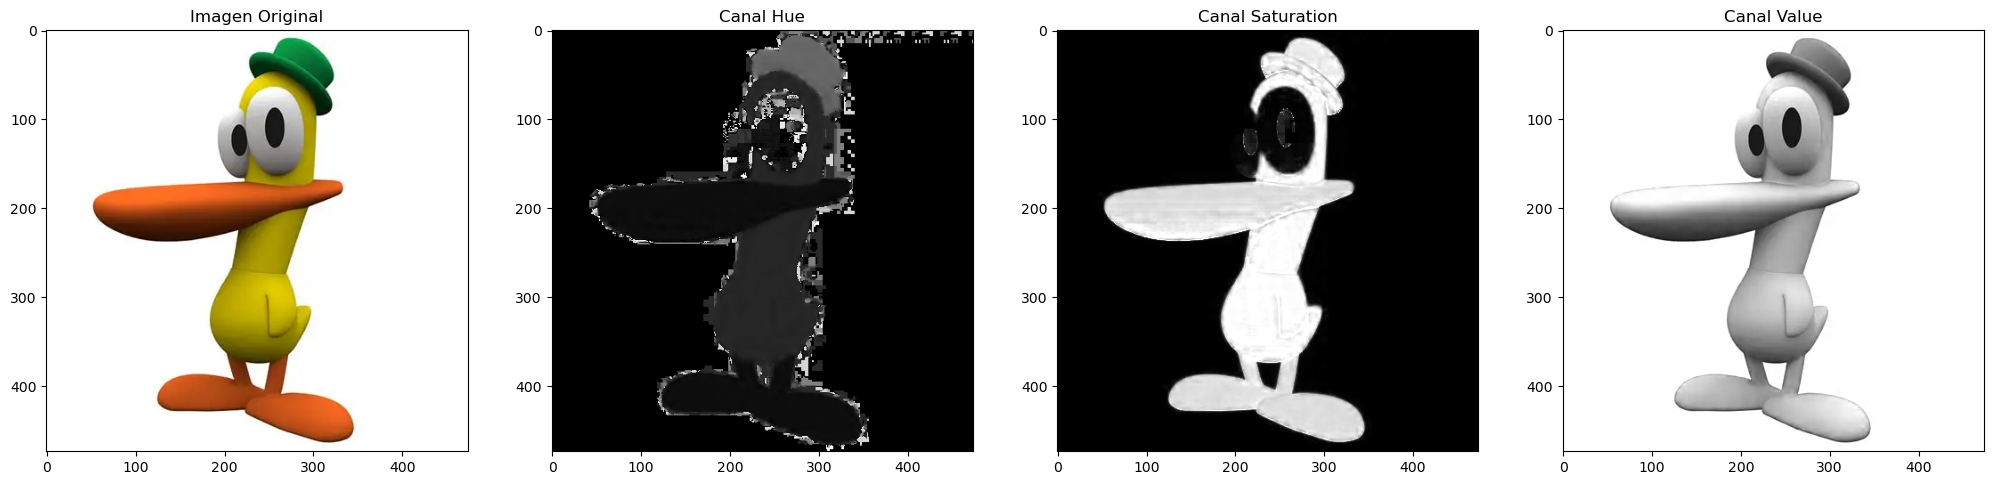

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen1 = cv2.imread('pato.jpg') 
img=cv2.cvtColor(imagen1, cv2.COLOR_BGR2RGB)
def RGB2HSV(img):
    img = img.astype(np.float32)
    img = img/255.
    new_img = np.zeros_like(img)

    maxChannel = np.argmax(img,axis=2)
    maxValue = np.amax(img,axis=2)
    minChannel = np.argmin(img,axis=2)
    minValue = np.amin(img,axis=2)
    #value 
    new_img[...,2] = maxValue

    #saturation
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j]==0:
                new_img[i,j,1] = 0
            elif maxValue[i,j] != 0:
                new_img[i,j,1] = (new_img[i,j,2]-minValue[i,j])/new_img[i,j,2]

    #hue 
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if sum(img[i,j,...])/3 == img[i,j,0]:
                new_img[i,j,0] = 0
            elif maxChannel[i,j] == 0: #R 
                new_img[i,j,0] = 60 * ((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))
            elif maxChannel[i,j] == 1: #G
                new_img[i,j,0] = 120 + 60 * (img[i,j,2]-img[i,j,0])/(new_img[i,j,2]-minValue[i,j])
            elif maxChannel[i,j] == 2: #B
                new_img[i,j,0] = 240 + 60 * (img[i,j,0]-img[i,j,1])/(new_img[i,j,2]-minValue[i,j])

        img2= new_img[...,0] < 0
        new_img[img2,0]   =  new_img[img2,0] + 360
    return new_img

hsv_img = RGB2HSV(img)
fig,axs = plt.subplots(1,4,figsize=(25,10))
axs[0].imshow(img)
axs[0].set_title('Imagen Original')

fig_img=axs[1].imshow(hsv_img[...,0], cmap='gray',vmin=0, vmax=360)
axs[1].set_title('Canal Hue')
fig_img=axs[2].imshow(hsv_img[...,1], cmap='gray',vmin=0, vmax=1)
axs[2].set_title('Canal Saturation')
fig_img=axs[3].imshow(hsv_img[...,2], cmap='gray',vmin=0, vmax=1)
axs[3].set_title('Canal Value')

## Mas optimizado la formula de conversion de rgb a hsv

Text(0.5, 1.0, 'Canal Value')

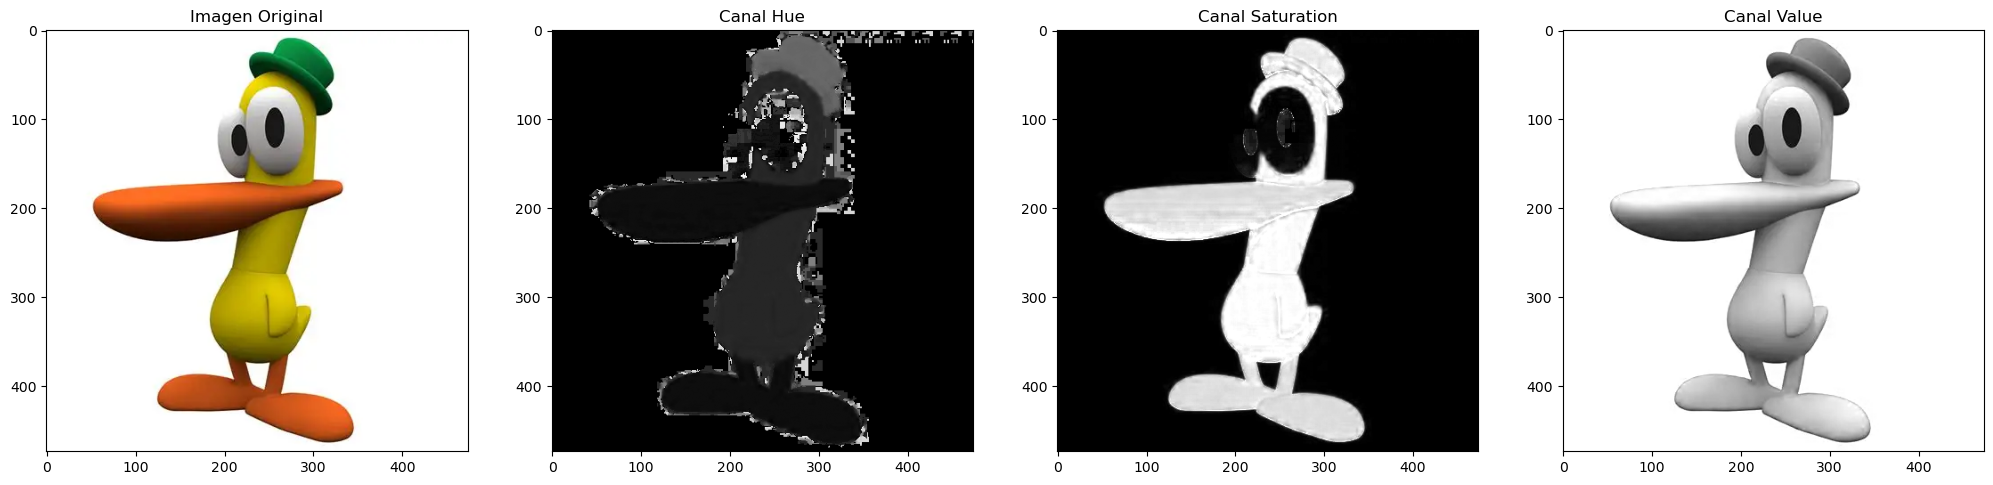

In [6]:
hsv_img_cv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
fig,axs = plt.subplots(1,4,figsize=(25,10))
axs[0].imshow(img)
axs[0].set_title('Imagen Original')

fig_img=axs[1].imshow(hsv_img_cv[...,0], cmap='gray',vmin=0, vmax=179)
axs[1].set_title('Canal Hue')
fig_img=axs[2].imshow(hsv_img_cv[...,1], cmap='gray',vmin=0, vmax=255)
axs[2].set_title('Canal Saturation')
fig_img=axs[3].imshow(hsv_img_cv[...,2], cmap='gray',vmin=0, vmax=255)
axs[3].set_title('Canal Value')

## de forma simple de rgb a hsv

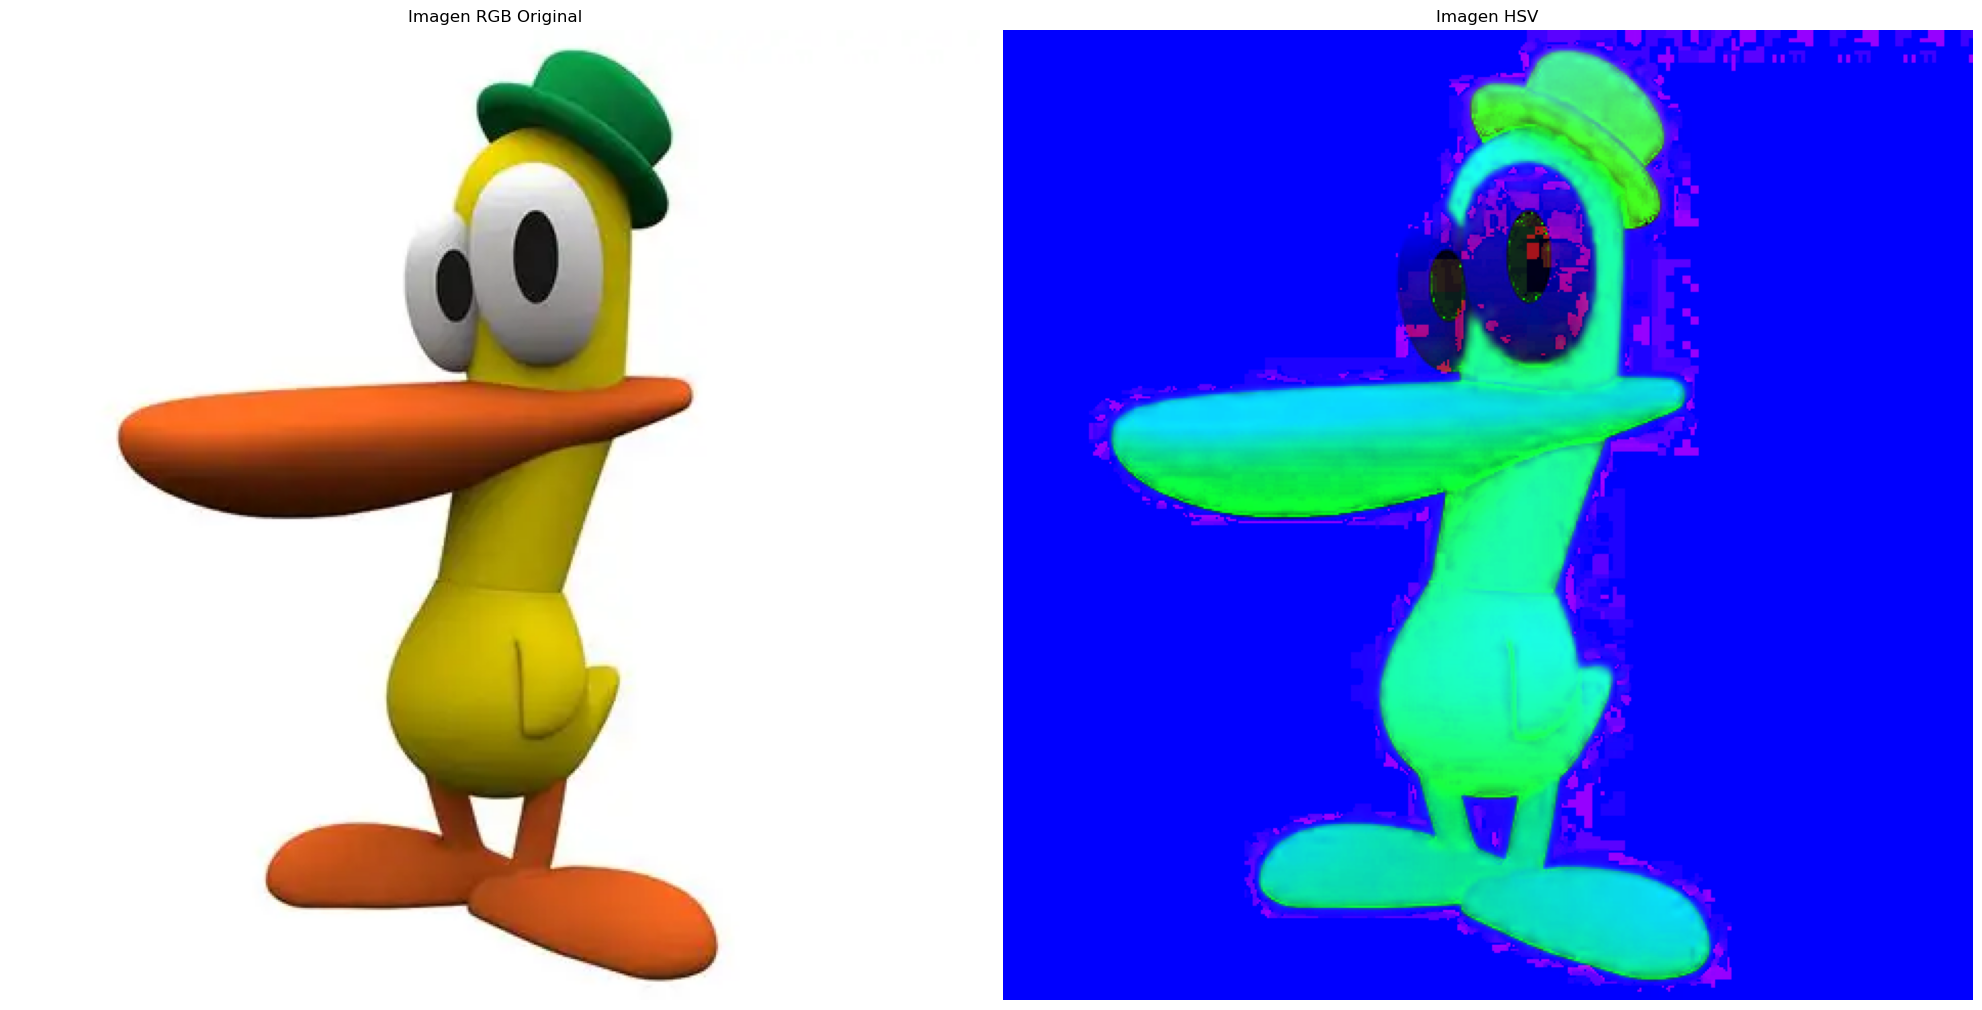

In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_rgb=cv2.cvtColor(cv2.imread('pato.jpg',cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

img_hsv=cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

fig,axs = plt.subplots(1,2,figsize=(20,10))

axs[0].imshow(img_rgb)
axs[0].set_title('Imagen RGB Original')
axs[0].axis('off')

axs[1].imshow(img_hsv)
axs[1].set_title('Imagen HSV')
axs[1].axis('off')

plt.tight_layout()
plt.show()

## hsv a rgb con formula de forma larga

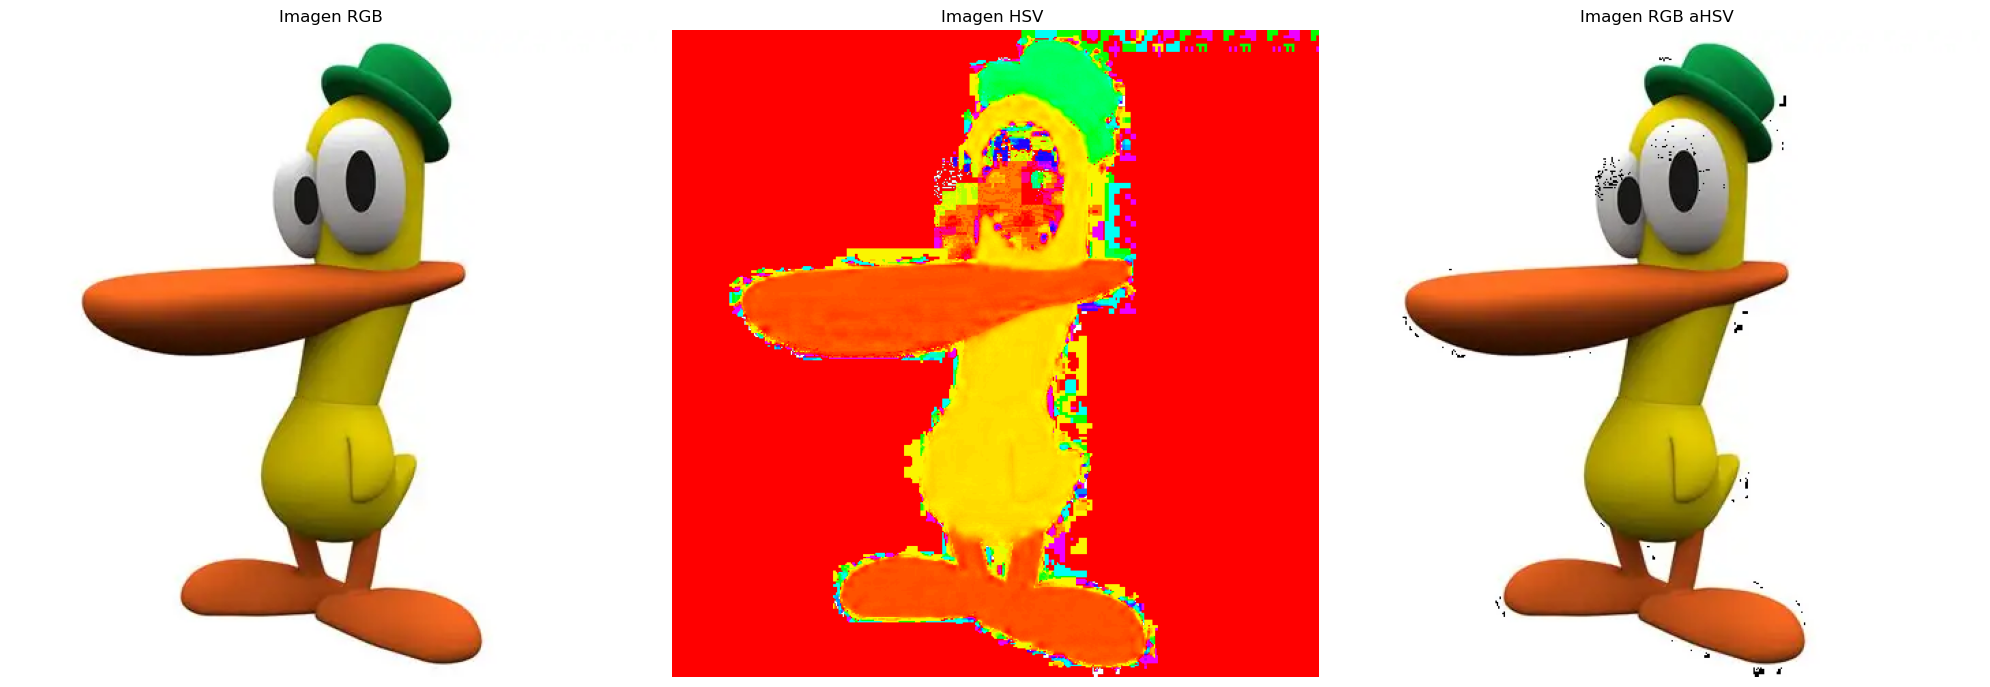

In [18]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def HSV2RGB(hsv_img):
    h = hsv_img[..., 0] 
    s = hsv_img[..., 1]  
    v = hsv_img[..., 2]  
    
    h60 = h / 60.0
    h60f = h60 - np.floor(h60)
    
    
    p = v * (1.0 - s)
    q = v * (1.0 - h60f * s)
    t = v * (1.0 - (1.0 - h60f) * s)
    
    rgb_img = np.zeros_like(hsv_img)
    
    mask = (h >= 0) & (h < 60)
    rgb_img[mask, 0] = v[mask]
    rgb_img[mask, 1] = t[mask]
    rgb_img[mask, 2] = p[mask]
    
    mask = (h >= 60) & (h < 120)
    rgb_img[mask, 0] = q[mask]
    rgb_img[mask, 1] = v[mask]
    rgb_img[mask, 2] = p[mask]
    
    mask = (h >= 120) & (h < 180)
    rgb_img[mask, 0] = p[mask]
    rgb_img[mask, 1] = v[mask]
    rgb_img[mask, 2] = t[mask]
    
    mask = (h >= 180) & (h < 240)
    rgb_img[mask, 0] = p[mask]
    rgb_img[mask, 1] = q[mask]
    rgb_img[mask, 2] = v[mask]
    
    mask = (h >= 240) & (h < 300)
    rgb_img[mask, 0] = t[mask]
    rgb_img[mask, 1] = p[mask]
    rgb_img[mask, 2] = v[mask]
    
    mask = (h >= 300) & (h < 360)
    rgb_img[mask, 0] = v[mask]
    rgb_img[mask, 1] = p[mask]
    rgb_img[mask, 2] = q[mask]
    
    return rgb_img

rgb_reconstruida = HSV2RGB(hsv_img)


fig, axs = plt.subplots(1, 3, figsize=(20, 10))

axs[0].imshow(img)
axs[0].set_title('Imagen RGB ')
axs[0].axis('off')

axs[1].imshow(hsv_img[...,0], cmap='hsv', vmin=0, vmax=360)
axs[1].set_title('Imagen HSV ')
axs[1].axis('off')

axs[2].imshow(rgb_reconstruida)
axs[2].set_title('Imagen RGB aHSV')
axs[2].axis('off')

plt.tight_layout()
plt.show()